# ETL — Telco Customer Churn

Notebook para la exploración de datos, detección de nulos y valores atípicos, creación de variables y guardado final de los datos que serán ocupados para el entrenamiento del modelo.

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 50)

RAW_PATH = "../data/churn.csv"
OUT_PATH = "../data/processed/churn_clean.csv"

Carga de datos

In [2]:
df = pd.read_csv(RAW_PATH)

print(f"Dimensiones del dataset: {df.shape}")

df.head()

Dimensiones del dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Valores nulos

Se analiza el dataset para la busqueda de valores nulos y atípicos.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


La variable `TotalCharges` queda como objeto cuando debería ser numérica. Ver los valores nulos.

In [4]:
for col in df.columns:

    print(f"La columna {col} tiene {df[col].isnull().sum()} valores nulos.")

La columna customerID tiene 0 valores nulos.
La columna gender tiene 0 valores nulos.
La columna SeniorCitizen tiene 0 valores nulos.
La columna Partner tiene 0 valores nulos.
La columna Dependents tiene 0 valores nulos.
La columna tenure tiene 0 valores nulos.
La columna PhoneService tiene 0 valores nulos.
La columna MultipleLines tiene 0 valores nulos.
La columna InternetService tiene 0 valores nulos.
La columna OnlineSecurity tiene 0 valores nulos.
La columna OnlineBackup tiene 0 valores nulos.
La columna DeviceProtection tiene 0 valores nulos.
La columna TechSupport tiene 0 valores nulos.
La columna StreamingTV tiene 0 valores nulos.
La columna StreamingMovies tiene 0 valores nulos.
La columna Contract tiene 0 valores nulos.
La columna PaperlessBilling tiene 0 valores nulos.
La columna PaymentMethod tiene 0 valores nulos.
La columna MonthlyCharges tiene 0 valores nulos.
La columna TotalCharges tiene 0 valores nulos.
La columna Churn tiene 0 valores nulos.


No hay valores nulos en el dataset pero falta ver en detalle la variable `TotalCharges`.

In [5]:
non_numeric_mask = pd.to_numeric(df["TotalCharges"], errors="coerce").isna()

print(f"Filas con TotalCharges no numérico: {non_numeric_mask.sum()}")

df.loc[non_numeric_mask, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

Filas con TotalCharges no numérico: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


Todas las filas con `TotalCharges` vacío tienen `tenure == 0`. Estos clientes están recién ingresados y por lo tanto no reciben su primera boleta. La regla de imputación es de negocio, no estadística: si no lleva ni un mes, el total facturado es 0.

In [6]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0.0)

assert df["TotalCharges"].isnull().sum() == 0

### Outliers en variables numéricas

Revisión de valores atípicos en las variables numéricas.

In [7]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"] # Senior Citizen es binaria, por lo que no se analiza

df[numeric_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


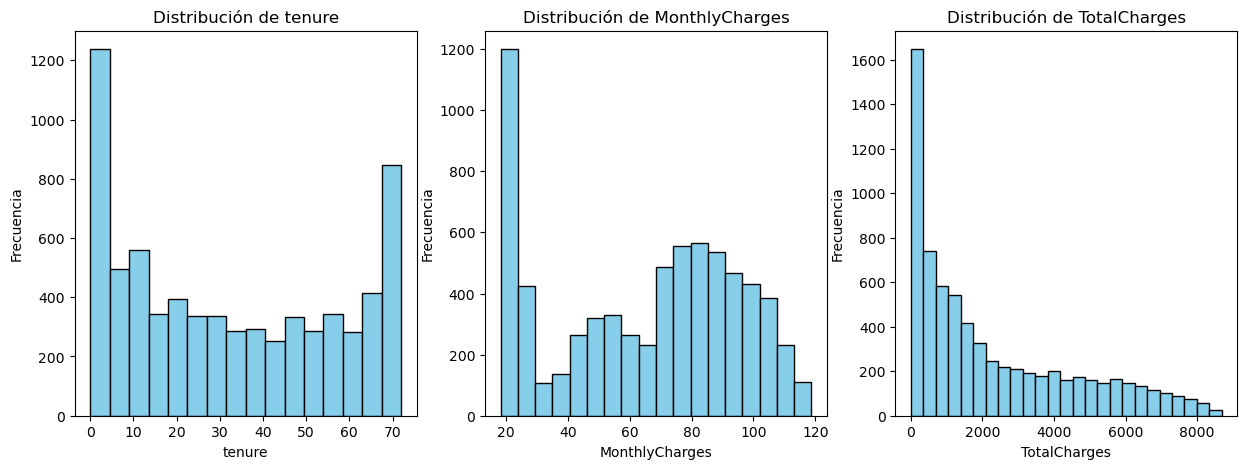

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    axes[i].hist(df[col], bins="auto", color="skyblue", edgecolor="black")
    
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")
    axes[i].set_title(f"Distribución de {col}")

Además de la revisión visual, agregar un análisis por IQR.

In [9]:
def iqr_outlier_report(series, name):
                       
    q1, q3 = series.quantile([0.25, 0.75])

    iqr = q3 - q1

    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    n_out = ((series < lower) | (series > upper)).sum()

    print(f"{name}: rango normal IQR [{lower:.1f}, {upper:.1f}]. Tiene {n_out} outliers ({n_out / len(series):.1%})")


for col in numeric_cols:

    iqr_outlier_report(df[col], col)

tenure: rango normal IQR [-60.0, 124.0]. Tiene 0 outliers (0.0%)
MonthlyCharges: rango normal IQR [-46.0, 171.4]. Tiene 0 outliers (0.0%)
TotalCharges: rango normal IQR [-4683.5, 8868.7]. Tiene 0 outliers (0.0%)


`tenure` y `MonthlyCharges` no tienen outliers relevantes por IQR: son variables acotadas por diseño del negocio (meses de contrato, tarifas de planes). `TotalCharges` puede marcar algunos "outliers" altos, pero son clientes antiguos con `tenure` grande. Dado que no hay señales de valores atípicos, se opta por no realizar limpieza de datos.

### Variables categóricas

Falta analizar las variables categóricas del set.

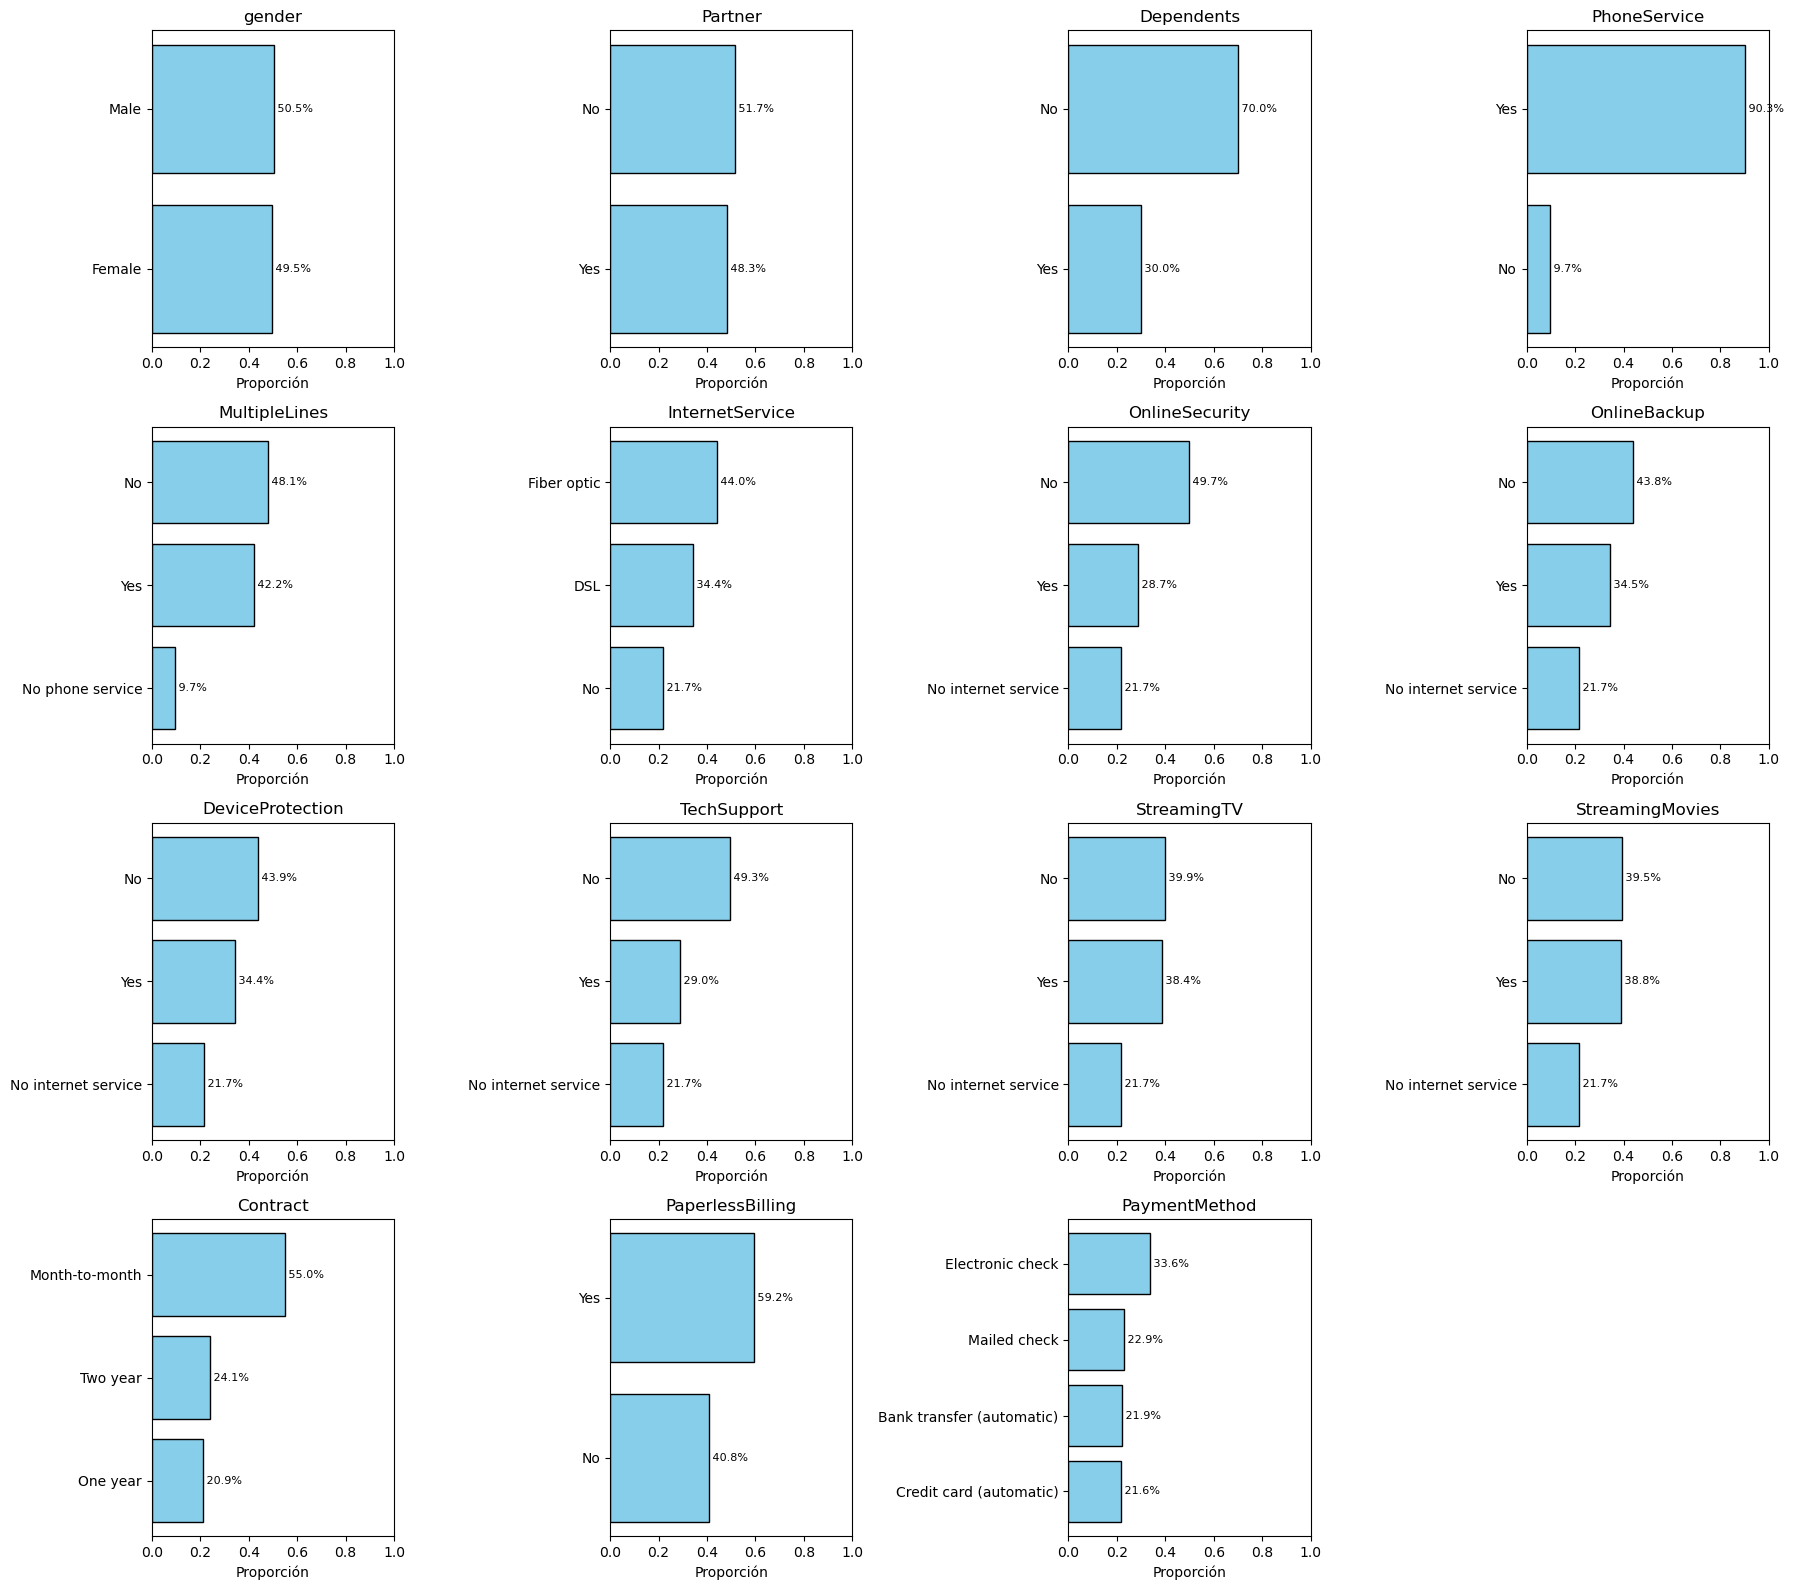

In [10]:
cat_cols = df.select_dtypes(include="object").columns.drop(["customerID", "Churn"])

n_cols = 4
n_rows = -(-len(cat_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):

    counts = df[col].value_counts(normalize=True).sort_values()

    ax.barh(counts.index, counts.values, color="skyblue", edgecolor="black")

    ax.set_xlabel("Proporción")
    ax.set_title(col)

    ax.set_xlim(0, 1)

    for i, v in enumerate(counts.values):
        ax.text(v, i, f" {v:.1%}", va="center", fontsize=8)

for ax in axes[len(cat_cols):]:
    
    ax.axis("off")

plt.tight_layout()
plt.show()

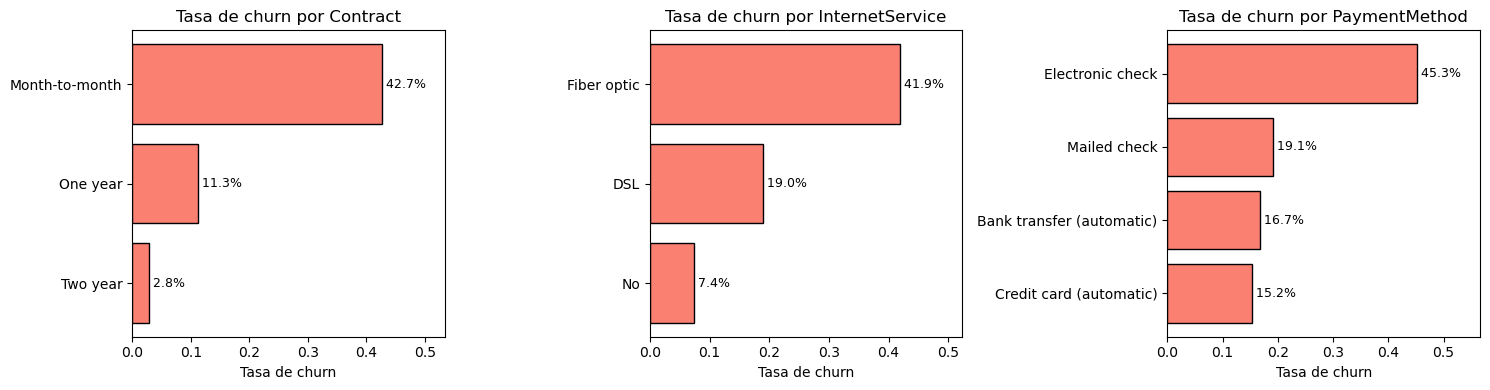

In [11]:
# tasa de churn por categoría, para las variables más relevantes al negocio
churn_cols = ["Contract", "InternetService", "PaymentMethod"]

fig, axes = plt.subplots(1, len(churn_cols), figsize=(15, 4))

for ax, col in zip(axes, churn_cols):
    rates = df.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean()).sort_values()

    ax.barh(rates.index, rates.values, color="salmon", edgecolor="black")
    ax.set_title(f"Tasa de churn por {col}")
    ax.set_xlabel("Tasa de churn")
    ax.set_xlim(0, rates.max() * 1.25)

    for i, v in enumerate(rates.values):
        ax.text(v, i, f" {v:.1%}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

El churn se concentra en contratos **month-to-month**, clientes con internet de **fibra óptica** y pago por **electronic check**. Son las tres señales más fuertes del dataset y justifican los features que se construyen a continuación.

### Feature engineering

Solo transformaciones determinísticas fila a fila. El one-hot encoding y el escalado quedan para `training/train.py`, ajustados únicamente sobre el train split.

In [12]:
service_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
]

# cuántos servicios adicionales tiene contratados (0-6): a más servicios, más "atado" está el cliente
df["num_add_on_services"] = (df[service_cols] == "Yes").sum(axis=1)

# tiene internet contratado o no (colapsa DSL/Fiber optic/No en una señal simple)
df["has_internet"] = (df["InternetService"] != "No").astype(int)

# bucket de antigüedad: la relación entre tenure y churn no es lineal
def tenure_bucket(months):

    if months <= 12:
        return "0-1y"
    
    if months <= 24:
        return "1-2y"
    
    if months <= 48:
        return "2-4y"
    
    return "4y+"

df["tenure_group"] = df["tenure"].apply(tenure_bucket)

# el contrato mes-a-mes fue la señal más fuerte de la sección 3: se aísla como flag binario
df["is_month_to_month"] = (df["Contract"] == "Month-to-month").astype(int)

# gasto mensual promedio real (evita dividir por tenure=0)
df["avg_monthly_spend"] = df["TotalCharges"] / df["tenure"].replace(0, 1)

# target a binario: esto es lo que predice el modelo
df["Churn"] = (df["Churn"] == "Yes").astype(int)

df = df.drop(columns=["customerID"])

### Guardar dataset procesado

In [13]:
os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)

df.to_csv(OUT_PATH, index=False)